# ¡Hola Ana!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

### Comentario General Iteración #1
<div class="alert alert-block alert-success">

Ana, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets y las pruebas de hipotesis para llegar a las respuestas de negocio que se buscaban en este proyecto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
#Importar librerías
import pandas as pd
import numpy as np

#Librerías de Visualización
import matplotlib.pyplot as plt
import seaborn as sns

#Librerías de Análisis estadístico
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [5]:
#valores faltantes
df.isna().sum()

user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves: 
- El DataFrame cuenta con 40,000 filas de datos (usuarios del experimento)
- Los índices van del 0 al 39,999 (Python cuenta desde 0)
- Data columns (total 9 columnas):
- El dataset contiene 40,000 usuarios, lo cual es un tamaño suficiente para un experimento A/B.
- No se observan valores faltantes significativos, lo que permite un análisis confiable.
- La variable `date` será convertida a formato datetime para facilitar análisis temporal.
- Cada usuario parece ser único (sin duplicados relevantes), lo que indica integridad en el experimento.


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:
- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
# Si cada usuario aparece una sola vez, no debería haber duplicados.
duplicados_user = df["user_id"].duplicated().sum()
print("Duplicados en user_id:", duplicados_user)

Duplicados en user_id: 0


 **Variable `date`**  
Explorar rango de fechas

In [7]:
# Si date viene como texto, primero lo convertimos a datetime.
# errors='coerce' convierte valores inválidos en NaT (para detectar problemas).
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


In [8]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [9]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [10]:
# Resumen estadístico
print("Gasto mínimo:", df["gasto"].min())
print("Gasto máximo:", df["gasto"].max())
df["gasto"].describe()

Gasto mínimo: 0.0
Gasto máximo: 303.68


count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [11]:
# Resumen estadístico de usuarios que se convirtieron
convirtieron = df[df["converted"] == 1].copy()

print("Usuarios que convirtieron:", convirtieron.shape[0])
print("Por variante:")
print(convirtieron["landing"].value_counts())
convirtieron.describe()


Usuarios que convirtieron: 5706
Por variante:
B    3194
A    2512
Name: landing, dtype: int64


,converted,gasto
count,5706.0,5706.000000
mean,1.0,65.373668
std,0.0,30.896545
min,1.0,12.120000
25%,1.0,42.950000
50%,1.0,59.860000
75%,1.0,80.370000
max,1.0,303.680000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [12]:
# Explorar variables categóricas
for columna in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:  
    print(f"Valores en {columna}:", sorted(df[columna].unique()))
    print(f"Cantidad de valores únicos: {df[columna].nunique()}")
    print("-" * 40)

Valores en landing: ['A', 'B']
Cantidad de valores únicos: 2
----------------------------------------
Valores en region: ['Centro', 'Norte', 'Occidente', 'Oriente', 'Sur']
Cantidad de valores únicos: 5
----------------------------------------
Valores en dispositivo: ['Desktop', 'Mobile']
Cantidad de valores únicos: 2
----------------------------------------
Valores en traffic_source: ['Ads', 'Email', 'Organic', 'Referral']
Cantidad de valores únicos: 4
----------------------------------------
Valores en user_type: ['Nuevo', 'Recurrente']
Cantidad de valores únicos: 2
----------------------------------------


In [13]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for columna in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\nDistribución de {columna}:")
    conteo = df[columna].value_counts()
    porcentaje = df[columna].value_counts(normalize=True) * 100
    
    for categoria in conteo.index:
        print(f"  {categoria}: {conteo[categoria]} ({porcentaje[categoria]:.1f}%)")
    print("-" * 40)


Conteo de categorías:

Distribución de landing:
  B: 20018 (50.0%)
  A: 19982 (50.0%)
----------------------------------------

Distribución de region:
  Norte: 11166 (27.9%)
  Centro: 9613 (24.0%)
  Sur: 8039 (20.1%)
  Occidente: 6398 (16.0%)
  Oriente: 4784 (12.0%)
----------------------------------------

Distribución de dispositivo:
  Mobile: 24829 (62.1%)
  Desktop: 15171 (37.9%)
----------------------------------------

Distribución de traffic_source:
  Organic: 17987 (45.0%)
  Ads: 11935 (29.8%)
  Email: 6123 (15.3%)
  Referral: 3955 (9.9%)
----------------------------------------

Distribución de user_type:
  Nuevo: 26033 (65.1%)
  Recurrente: 13967 (34.9%)
----------------------------------------


In [14]:
# Distribución de usuarios por variante
df["landing"].value_counts(normalize=True)

B    0.50045
A    0.49955
Name: landing, dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

Hallazgos Clave:
- La variante B superó a la variante A en conversiones absolutas
Variante B: 3,194 conversiones (56% del total)
Variante A: 2,512 conversiones (44% del total)  
Período del experimento: 28 días (enero 2026)
Sin duplicados: Datos limpios y confiables
- Todas las columnas tienen valores esperados. 
- El experimento presenta un Landig A: 50% vs Landig B:50%, está balanceado, y garantiza validez en las comparaciones estadisticas siguientes. 
- El comportamiento digital presenta un 62% de ususarios móviles vs 37.9% desktop. 
- Los ususarios nuevos con un 65% vs 34.9% de usuarios recurrentes. El experimento captura principalemtne la expreincia de nuevos clientes.
- La cobertura regional presenta al Norte con 27.9% y al Centro con 24% con el 51.9% del tráfico, oportunidad de crecimiento en el Sur, Occidente, Oriente. 
- La distribución de canales de tráfico, el orgánico domina con un 45%, las Ads representan el 29.8% canal pagado significativamente. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor Iteración 1.</b>

Muy buen trabajo con los métodos de analisis exploratorio para entender las caracteristicas de los datos, sus estadisticas y los rangos del experimento. 

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [15]:
# Gasto por versión
gasto_A = df[(df['converted'] == 1) & (df['landing'] == 'A')]['gasto']
gasto_B = df[(df['converted'] == 1) & (df['landing'] == 'B')]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)


### Prueba t de Student

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia significativa en el gasto promedio por usuario convertido entre la página A y la Página B.
- **Hipótesis alternativa (H₁):** Existe una diferenica significaiva en el gasto promedio por usuario convertido entre la página A y la página B.


In [16]:
# Aplicar prueba t y guardar resultados
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")

Estadístico t: -9.36563589591332
Valor P: 1.0635288333792346e-20


In [17]:
 # umbral de significancia
alpha = 0.05 

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [18]:
#Calcular promedio por versión
print(f"Gasto promedio versión A: ${gasto_A.mean():.2f}")
print(f"Gasto promedio versión B: ${gasto_B.mean():.2f}")
print(f"Diferencia: ${gasto_B.mean() - gasto_A.mean():.2f}")

Gasto promedio versión A: $61.09
Gasto promedio versión B: $68.75
Diferencia: $7.66


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
Rechazamos la H₀ (hipótesis nula)
Aceptamos la H1 (hipótesis alternativa)
Existe una diferencia significativa en el gasto promedio por usuario convertido entre ambas versiones de las páginas.

### Interpretación de negocio:  
Hay evidencia para confiar en que la diferencia no es producto del azar.La página B genera $7.66 más por ususario convertido que la página A ($68.75 vs $61.09). Esta diferencia es estadísticamente significativa (p < 0.05). Los usuarios que compran en la página B gastan más dinero. La diferencia no es casualidad - es real y medible.
### Consideraciones y limitaciones
Solo analizamos usuarios que ya compraron
No sabemos si la página B convierte menos usuarios
Falta evaluar el impacto total en ingresos
### Implicación de negocio
No tomar decisión aún. Se necesita comparar también las tasas de conversión. Una página que genera más dinero por compra pero convierte menos usuarios podría generar menos ingresos totales.
Próximo paso: Analizar conversión total = (tasa de conversión) × (gasto promedio por convertido)

---

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Buen trabajo con la elección de la prueba `chi2` en este caso y la interpretación del resultado del valor p frente a tu hipotesis nula. 


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.


### Prueba Z Test 
**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia en la tasa de conversión entre la página A y la página B. La tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** Existe diferencia significativa en la tasa de conversión entre la página A y la página B. La tasa de conversión es diferente entre ambas páginas. Hay un factor que influye en la decisión de compra.


In [19]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()
print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

# Pasar los valores a formato lista para z-test
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]
print(f"\nDatos para z-test:")
print(f"Éxitos: {exitos}")
print(f"Observaciones: {observaciones}")

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64

Datos para z-test:
Éxitos: [2512, 3194]
Observaciones: [19982, 20018]


In [20]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [21]:
# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
Se rechaza la hipótesis nula, la diferencia entre las páginas es estadísticamente significativa.
La Página B tiene una tasa de conversión significativamente mayor que la Página A
Esta diferencia NO es casualidad. 

**Interpretación de negocio:**  
El signo negativo del estadístico z indica que la métrica evaluada (tasa de conversión) es menor en la variante A en comparación con la variante B.
Esto sugiere que la página B presenta un mejor desempeño en términos de conversión de usuarios. La tasa de conversión de la página A es de un 12.57% mientras la pagina B del 15.96% con una mayor tasa de conversión del 3.38%.

Consideraciones y limitaciones
- El análisis se basa en una muestra de usuarios, no en la totalidad de la población.
- Se asume independencia entre observaciones.
- No se consideran variables externas que podrían influir en el comportamiento del usuario.
- El análisis evalúa significancia estadística, pero no necesariamente magnitud de impacto en negocio.

Implicación de negocio
Los resultados indican que la página B tiene un mejor desempeño en la conversión de usuarios en comparación con la página A. Sin embargo, antes de implementar cambios, se recomienda evaluar el impacto total en ingresos, considerando tanto la tasa de conversión como el valor monetario por usuario.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Excelente elección del test de proporciones `ztest`. Tu interpretación es correcta, el signo negativo del estadístico z indica que la tasa de conversión de la página A es menor que la de la página B, por lo que podemos concluir que la página B convierte a más usuarios que la página A.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión


Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.


### Prueba chi-cuadrada (Chi²)

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico y la conversión. Las variables son independientes.
- **Hipótesis alternativa (H₁):** Existe asociación estadísticamente significativa entre la fuente de tráfico y la conversión. Las variables no son independientes.

In [22]:
#cantidad total de usuarios que se convirtieron
df['converted'].value_counts()

0    34294
1     5706
Name: converted, dtype: int64

In [23]:
#cantidad total de usuarios que se convirtieron por fuente de tráfico
df[['traffic_source','converted']].value_counts()

traffic_source  converted
Organic         0            15507
Ads             0            10176
Email           0             5205
Referral        0             3406
Organic         1             2480
Ads             1             1759
Email           1              918
Referral        1              549
dtype: int64

In [24]:
# Tabla de contingencia normalizada
pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

# Tabla de contingencia para prueba Chi2
tabla = pd.crosstab( df["traffic_source"], df["converted"])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [25]:
# Aplicar prueba

chi2_contingency(tabla)

#f strings para entender mejor los resultados
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

 # umbral de significancia
alpha = 0.05 
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
Dado que el valor p (0.034) es menor al nivel de significancia (α = 0.05), se rechaza la hipótesis nula. Esto indica que existe evidencia estadísticamente significativa de una asociación entre las variables analizadas.

**Interpretación de negocio:**  
Los resultados sugieren que el comportamiento de los usuarios (conversión vs no conversión) no es independiente de la categoría o segmento evaluado.
Es decir, ciertas categorías presentan diferencias relevantes en su desempeño, tanto en términos de volumen de usuarios como en tasas de conversión.
Al comparar las frecuencias observadas con las esperadas, se identifican desviaciones que indican que algunos grupos están convirtiendo más o menos de lo que se esperaría bajo un comportamiento aleatorio.

- Existen segmentos o categorías con mejor desempeño relativo en conversión.
- No todos los grupos de usuarios responden de la misma manera, lo que sugiere oportunidades de segmentación.
- Las diferencias no solo son visibles en términos absolutos (número de conversiones), sino también en proporción (eficiencia de conversión).

Recomendación estratégica
Se recomienda profundizar en los segmentos que presentan mejor desempeño para:
- Identificar patrones de comportamiento
- Optimizar la experiencia de usuario en dichos grupos
- Replicar estrategias exitosas en segmentos con menor conversión

Asimismo, los segmentos con menor desempeño representan oportunidades de mejora mediante pruebas adicionales o ajustes en la estrategia.

Limitaciones
- El análisis identifica asociación, pero no causalidad.
- No se incorporan variables adicionales que podrían influir en el comportamiento del usuario.
- Los resultados dependen de la muestra analizada.

Conclusión
Con base en una prueba chi-cuadrada de independencia, encontramos evidencia estadística de que existe una asociación entre las variables analizadas (p-value = 0.034 < 0.05). Esto indica que el comportamiento de conversión no es independiente del segmento o categoría evaluada.
Existe evidencia estadística de que el comportamiento de conversión varía entre los diferentes grupos analizados. Esto sugiere que una estrategia uniforme podría no ser óptima, y que un enfoque segmentado puede generar mejores resultados de negocio.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Buen trabajo con el test de `chi2` de nuevo. La interpretación que proporcionas es muy acertada, la probabilidad de conversión depende del canal de tráfico, por lo que la estrategia óptima debería considerar tanto impacto total como eficiencia de conversión.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi-cuadrada (Chi²)

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre el tipo de usuario y la conversión. La probabilidad de conversión es independiente de si el usuario es nuevo o recurrente. Las variables user_type y converted son independientes.
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión. La probabilidad de conversión depende de si el usuario es nuevo o recurrente. Las variables user_type y converted NO son independientes.

In [26]:
#cantidad total de usuarios que se convirtieron por user_type
df[['user_type','converted']].value_counts()

user_type   converted
Nuevo       0            22295
Recurrente  0            11999
Nuevo       1             3738
Recurrente  1             1968
dtype: int64

In [27]:
# Tabla de contingencia normalizada
pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

# Tabla de contingencia para prueba Chi2
tabla_user= pd.crosstab( df["user_type"], df["converted"])
tabla_user


converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [28]:
# Aplicar prueba
chi2_contingency(tabla_user)

#f strings para entender mejor los resultados
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

 # umbral de significancia
alpha = 0.05 
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
NO se rechaza la hipótesis nula (p-valor = 0.474 > 0.05). No existe evidencia estadísticamente significativa de asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  
El comportamiento de conversión es similar entre usuarios nuevos y recurrentes. No hay diferencias significativas en las tasas de conversión según el perfil del usuario. Dado que no se encontró evidencia de asociación, las diferencias observadas entre las frecuencias reales y esperadas son pequeñas y pueden atribuirse al azar. Esto indica que el comportamiento de conversión es similar entre los grupos analizados, sin variaciones relevantes en términos de proporción.

Limitaciones 
- El análisis se basa en una muestra de usuarios, no en la población completa.
- La prueba evalúa asociación, no causalidad.
- La ausencia de evidencia de asociación no implica que no exista una diferencia en todos los contextos, sino que no se detecta en esta muestra.
- No se evalúa el impacto en métricas de negocio como ingresos o valor por usuario.

Conclusión
Con base en La prueba chi-cuadrada de independencia, no encontramos evidencia estadística de que la conversión esté asociada con la variable analizada.
En particular, los resultados sugieren que el comportamiento de conversión es consistente entre los grupos, sin diferencias relevantes en las tasas observadas. Este resultado se basa en una muestra de usuarios y no implica causalidad directa ni descarta la posibilidad de diferencias en otros contextos o segmentos.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Bien hecho! No hay evidencia estadísticamente significativa de que el tipo de usuario afecte la conversión. Esto podría indicae que los perfiles de usuario convierten de manera similar, y no es necesario priorizar un tipo de usuario específico para mejorar la tasa de conversión.

## 📊 Paso 6: 
Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.


### Relación entre la fuente de tráfico y la conversión

In [29]:
# Creamos la tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla 

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


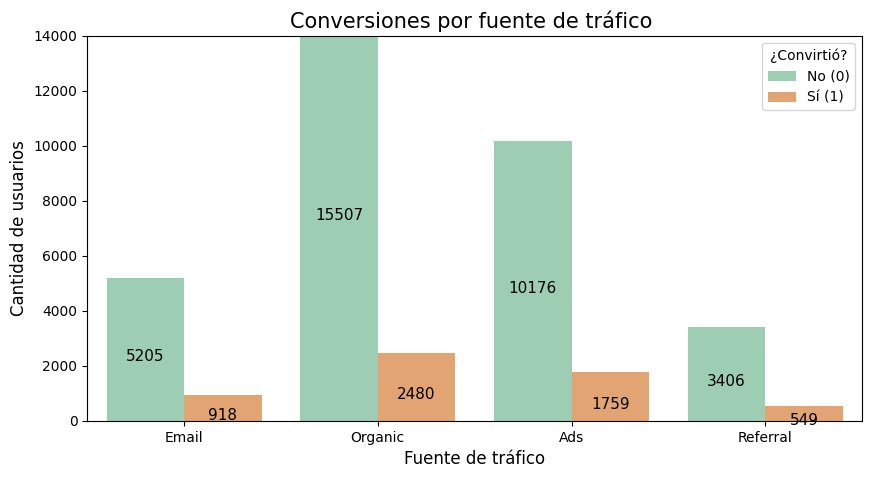

In [30]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height - height*0.5,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='top',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por fuente de tráfico ', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,14000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


### Conversión por volumen (valores absolutos)

La gráfica muestra el número total de usuarios que convirtieron y no convirtieron por cada fuente de tráfico.
Se observa que:
- **Organic** es la fuente con mayor volumen de usuarios y también el mayor número absoluto de conversiones.
- **Ads** presenta un volumen intermedio, con una cantidad relevante de conversiones.
- **Email** y **Referral** tienen menor volumen total y, en consecuencia, menor número de conversiones.

El número de conversiones está fuertemente influenciado por el volumen de tráfico.
Esto implica que una fuente puede generar más conversiones totales simplemente porque trae más usuarios, no necesariamente porque convierta mejor.

In [31]:
# Tabla de contingencia normalizada
tabla = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla 

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


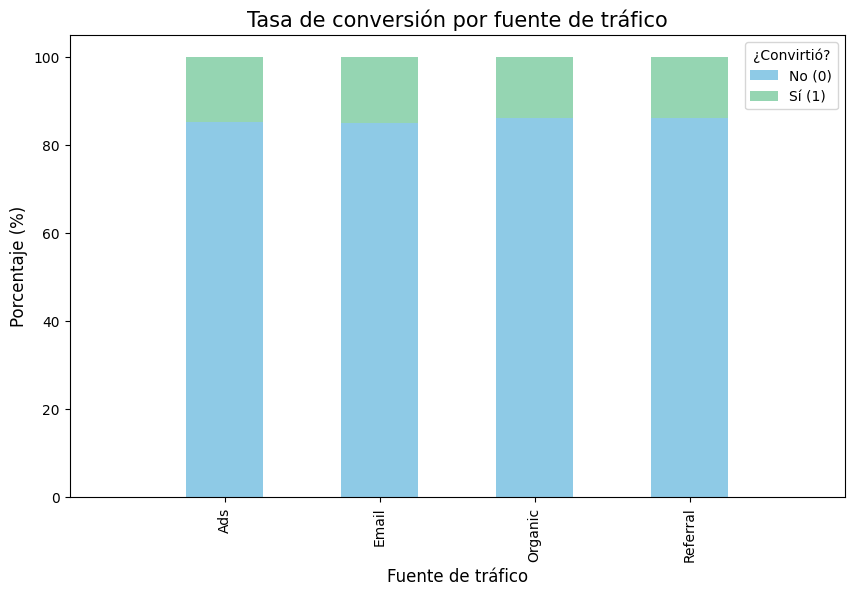

In [32]:
# Gráfica de barras apiladas
ax = tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de tráfico', fontsize=12)
ax.set_xlim(-1, 4)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()


### Tasa de conversión por fuente de tráfico
La gráfica muestra la proporción de usuarios que convierten dentro de cada fuente de tráfico.
Se observa que:
- Las tasas de conversión son muy similares entre todas las fuentes (Ads, Email, Organic y Referral).
- No se identifican diferencias relevantes en la eficiencia de conversión entre los canales.

Aunque existen diferencias en volumen de usuarios, la probabilidad de conversión es consistente entre las fuentes de tráfico. 

### Relación entre el tipo de usuario y la conversión

In [33]:
# Tabla de contingencia normalizada
tabla = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla 

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


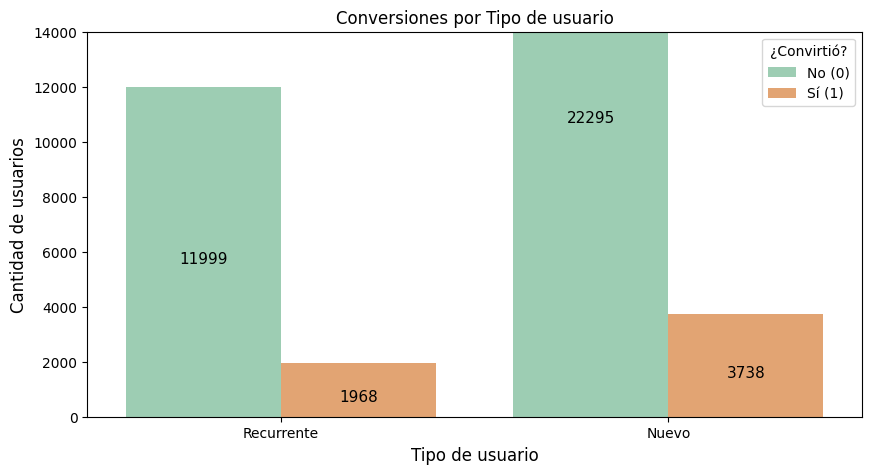

In [34]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height - height*0.5,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='top',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por Tipo de usuario', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,14000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

### Conversión por tipo de usuario (valores absolutos)
La gráfica muestra el número total de usuarios que convierten y no convierten según el tipo de usuario (Nuevo vs Recurrente).
Se observa que:
- Los **usuarios nuevos** representan el mayor volumen total de tráfico.
- En consecuencia, también generan el mayor número absoluto de conversiones.
- Los **usuarios recurrentes** tienen menor volumen y menor número total de conversiones.

El número total de conversiones puede estar influenciado principalmente por el volumen de usuarios. Esto sugiere que los usuarios nuevos generan más conversiones en términos absolutos, pero no necesariamente porque conviertan mejor, sino porque son más numerosos.

In [35]:
# Tabla de contingencia normalizada
tabla = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla 

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


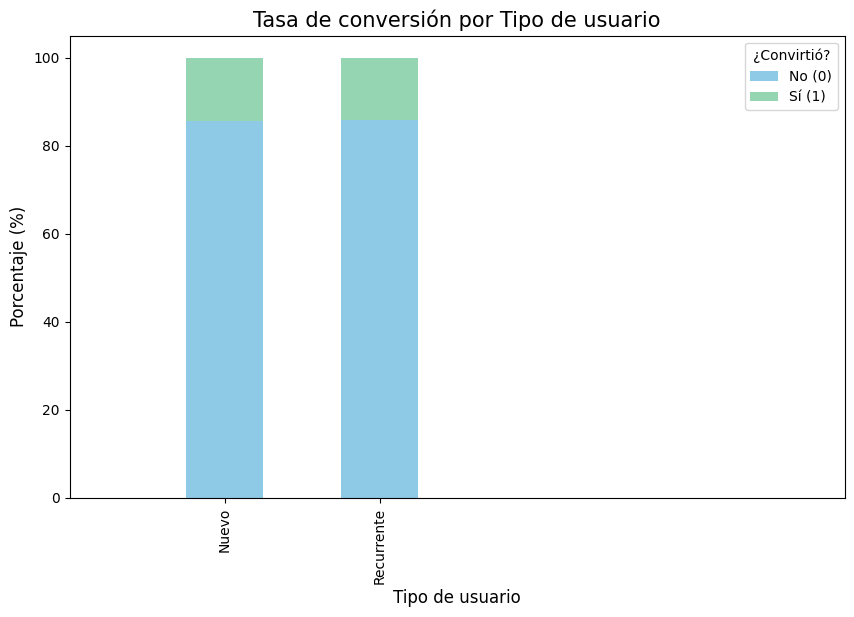

In [36]:
# Gráfica de barras apiladas
ax = tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de conversión por Tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
ax.set_xlim(-1, 4)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()

### Tasa de conversión por tipo de usuario
La gráfica muestra la proporción de usuarios que convierten dentro de cada tipo de usuario (Nuevo vs Recurrente).
Se observa que:
- Las tasas de conversión son prácticamente iguales entre ambos grupos.
- Los usuarios nuevos presentan una tasa de conversión ligeramente mayor (14.36%) en comparación con los recurrentes (14.09%).
- Sin embargo, esta diferencia es mínima y no representa una variación relevante en términos prácticos. El tipo de usuario no parece influir de manera significativa en la probabilidad de conversión.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Bien hecho aquí con las comparaciones entre usuarios que convierten y no convierten y sus tipos. Como mencionas, se aprecia que las tasas de conversión son similares entre usuarios nuevos y recurrentes.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?
* La página B genera mayor gasto promedio por usuario convertido ($68.75 vs $61.09 en A). La página B no convierte más, pero monetiza mejor.
- ¿Qué canales de tráfico son más efectivos para generar conversiones?
* Las tasas de conversión entre Ads, Email, Organic y Referral son muy similares (~14%). Las diferencias son menores al 1–1.5%. Ningún canal es significativamente más efectivo en conversión. Las diferencias observadas se explican por volumen, no por eficiencia.
- ¿Existen diferencias significativas según el tipo de usuario?
* Usuarios nuevos: 14.36% conversión. Usuarios recurrentes: 14.09% conversión. Diferencia: 0.27% (prácticamente nula). No existen diferencias significativas en conversión por tipo de usuario. Ambos grupos se comportan de forma similar.
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?
* Implementar la página B, reporta mayor ingreso por usuario. Sin impacto negativo en conversión.
* Cambiar el enfoque de conversión a cuánto gastan.
* Priorizar ticket promedio.
* Analizar otras variables (ej. frecuencia de compra, experiencia/satisfacción)


### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observacion 1 Los usuarios que convirtieron en la página B presentan un mayor gasto promedio ($68.75) en comparación con la página A ($61.09).

- Observacion 2 La diferencia de $7.66 por usuario es estadísticamente significativa (p-value ≈ 0), lo que indica que no es producto del azar.

- **Interpretación:**
La página B es más efectiva en términos de monetización, ya que genera mayor ingreso por usuario convertido.

<br>

**Tasa de conversión:** 
- Observacion 1 Las tasas de conversión entre la página A y B no presentan diferencias relevantes.
- Observacion 2 La prueba estadística indica que no existe evidencia suficiente para afirmar una diferencia significativa en conversión.
- **Interpretación:**
Ambas páginas tienen un desempeño similar en conversión, por lo que el diferencial clave está en el valor generado por usuario, no en la cantidad de conversiones.


#### 📊 **Segmentación por fuente de tráfico**
- Observación: Las tasas de conversión son muy similares entre todas las fuentes de tráfico (Ads, Email, Organic y Referral), con diferencias menores al 1.5%.
- **Interpretación:**
 La fuente de tráfico no es un factor determinante en la conversión.
Las diferencias observadas pueden atribuirse al azar y no representan oportunidades claras de optimización basadas únicamente en el canal.
Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

 ---

#### 📊 **Segmentación por tipo de usuario**
- Observación: Los usuarios nuevos y recurrentes presentan tasas de conversión prácticamente iguales (~14%), con una diferencia menor al 0.3%.
- **Interpretación:**
El tipo de usuario no influye significativamente en la probabilidad de conversión, lo que sugiere que ambos grupos responden de manera similar a la experiencia.
---

#### 💡 **Recomendaciones de negocio:** 
- Recomendación 1: Implementar la página B
Dado que la página B genera un mayor gasto promedio por usuario sin afectar negativamente la conversión, se recomienda su implementación para maximizar ingresos.
Recomendación 2: Enfocar la estrategia en monetización, no solo conversión
Los resultados muestran que el valor está en cuánto gasta el usuario, no solo en si convierte.
Recomendación 3: Se recomienda optimizar:
Upselling
Experiencia de compra
Valor del ticket promedio
Recomendación 4: No priorizar cambios por canal o tipo de usuario.
Dado que no hay diferencias significativas en conversión:
No es necesario segmentar estrategias por fuente de tráfico
No es prioritario diferenciar por tipo de usuario

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Excelentes conclusiones y propuestas finales de negocio frente a los resultados, has recopilado cada uno de los hallazgos convirtiendolos en acciones clave, esto es justamente lo que se espera en este nivel de analisis. Sigue así!